In [2]:
import os
wdir=!echo $PWD
os.chdir("/home6/afahad/.ipython/")
from aoespy import *
os.chdir(wdir[0])

/home6/afahad/.ipython/aoespy.py:19: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
import xarray as xr
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

In [4]:
ME5061=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_cape/200505/*cape*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-14'))

In [5]:
ME506s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [6]:
RP5061=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP05062/holding/geosgcm_cape/200505/*cape*200505*z.nc4')


In [7]:
# RP5061=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_prog/200505/*prog*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [8]:
RP506s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP05062/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [9]:
ME5061=ME5061.sel(time=slice('2005-05-05','2005-05-14'))
ME506s=ME506s.sel(time=slice('2005-05-05','2005-05-14'))
RP5061=RP5061.sel(time=slice('2005-05-05','2005-05-14'))
RP506s=RP506s.sel(time=slice('2005-05-05','2005-05-14'))

In [11]:
import dask

# Set the default scheduler to synchronous
dask.config.set(scheduler='synchronous')

In [12]:
# cape=ME5061.CAPE[2::3].compute()
cape=ME5061.CAPE[::1].compute()
T=ME5061.T[::1].compute()
lh=ME506s.LHFX.compute()
omg=ME5061.OMEGA[::1].sel(lev=500).compute()
sf=ME506s.SHFX.compute()
tsa=ME506s.TA.compute()
ts=ME506s.TS_FOUND.compute()
sw=ME506s.SWGNET.compute()
sw=sw.resample(time='1D').mean()
ts=ts[1:,:,:]-ts[:-1,:,:].data

In [13]:
# cape=RP5061.CAPE[2::3].compute()
caper=RP5061.CAPE[::1].compute()
Tr=RP5061.T[::1].compute()
lhr=RP506s.LHFX.compute()
omgr=RP5061.OMEGA[::1].sel(lev=500).compute()
sfr=RP506s.SHFX.compute()
tsar=RP506s.TA.compute()
tsr=RP506s.TS_FOUND.compute()
swr=RP506s.SWGNET.compute()
swr=swr.resample(time='1D').mean()
tsr=tsr[1:,:,:]-tsr[:-1,:,:].data

In [14]:
ticks=[]

for i in range(len(sf.time)):
    ticks=append(ticks,str(sf.time.data[i])[5:10])
    

In [15]:
ticks2=[]

for i in range(len(cape.time)):
    ticks2=append(ticks2,str(cape.time.data[i])[5:10])
    

In [16]:
ticks1=[]

for i in range(len(sw.time)):
    ticks1=append(ticks1,str(sw.time.data[i])[5:10])
    

In [17]:
ticks6=[]

for i in range(len(omgr.time)):
    ticks6=append(ticks6,str(omgr.time.data[i])[5:10])
    

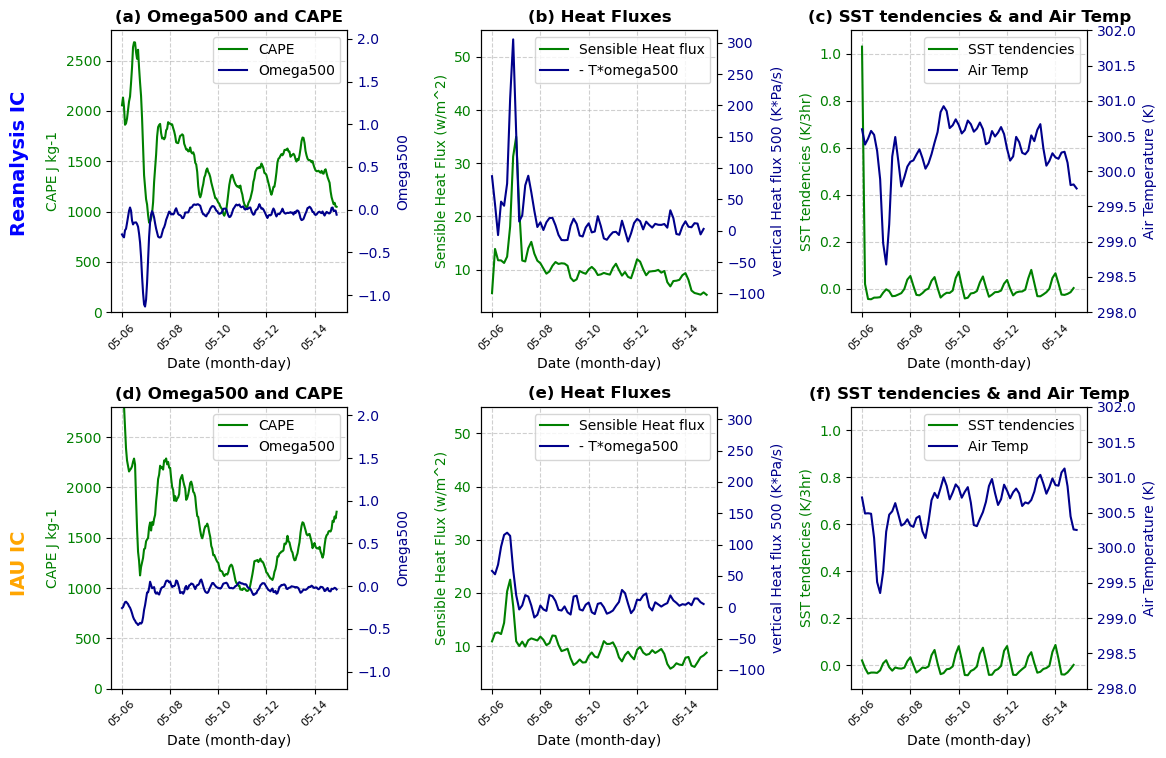

In [19]:
x1 = 143
x2 = 143
y1 = -1
y2 = -1

fig= plt.figure(figsize=(12, 8))
fig.text(0.04, 0.75, 'Reanalysis IC', va='center', ha='center', rotation='vertical', fontsize=14, fontweight='bold',color='blue')

ax1 = plt.subplot(2, 3, 1)
plt.title('(a) Omega500 and CAPE', fontsize=12, fontweight='bold')

# Plot 'sf' (Sensible Heat) on the first y-axis (left)
color3 = 'green'
ax1.set_xlabel('Date (month-day)')
ax1.set_ylabel('CAPE J kg-1', color=color3)
line1 = ax1.plot((cape).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color3, label='CAPE')
ax1.tick_params(axis='y', labelcolor=color3)
ax1.set_xticks(np.arange(len(ticks2))[::48])
ax1.set_xticklabels(ticks2[::48], fontsize=8, rotation=45)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(0,2800)
# Create a second y-axis that shares the same x-axis
ax4 = ax1.twinx()

# Plot 'lh' (Latent Heat) on the second y-axis (right)
color4 = 'darkblue'
ax4.set_ylabel('Omega500', color=color4)
line4 = ax4.plot((omg).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color4, label='Omega500')
ax4.tick_params(axis='y', labelcolor=color4)
ax4.set_ylim(-1.2,2.1)

# Create a combined legend for both lines
lines_3_4 = line1 + line4
labels_3_4 = [l.get_label() for l in lines_3_4]
ax1.legend(lines_3_4, labels_3_4, loc='best')





ax3 = plt.subplot(2, 3, 2)
plt.title('(b) Heat Fluxes', fontsize=12, fontweight='bold')

# Plot 'sf' (Sensible Heat) on the first y-axis (left)
color3 = 'green'
ax3.set_xlabel('Date (month-day)')
ax3.set_ylabel('Sensible Heat Flux (w/m^2)', color=color3)
line3 = ax3.plot((sf).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color3, label='Sensible Heat flux')
ax3.tick_params(axis='y', labelcolor=color3)
ax3.set_xticks(np.arange(len(ticks))[::16])
ax3.set_xticklabels(ticks[::16], fontsize=8, rotation=45)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.set_ylim(2,55)
# Create a second y-axis that shares the same x-axis
ax4 = ax3.twinx()

# Plot 'lh' (Latent Heat) on the second y-axis (right)
color4 = 'darkblue'
ax4.set_ylabel('vertical Heat flux 500 (K*Pa/s)', color=color4)
line4 = ax4.plot(((-T.sel(lev=500)*omg.data)[2::3]).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color4, label='- T*omega500')
ax4.tick_params(axis='y', labelcolor=color4)
ax4.set_ylim(-130,320)

# Create a combined legend for both lines
lines_3_4 = line3 + line4
labels_3_4 = [l.get_label() for l in lines_3_4]
ax3.legend(lines_3_4, labels_3_4, loc='best')


ax1 = plt.subplot(2, 3, 3)
plt.title('(c) SST tendencies & and Air Temp', fontsize=12, fontweight='bold')

# Plot 'ts' on the first y-axis (left)
color1 = 'green'
ax1.set_xlabel('Date (month-day)')
ax1.set_ylabel('SST tendencies (K/3hr)', color=color1)
line1 = ax1.plot((ts).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color1, label='SST tendencies')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(np.arange(len(ticks))[::16])
ax1.set_xticklabels(ticks[::16], fontsize=8, rotation=45)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot 'tsa' on the second y-axis (right)
color2 = 'darkblue'
ax2.set_ylabel('Air Temperature (K)', color=color2)
line2 = ax2.plot((tsa).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color2, label='Air Temp')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(298,302)
ax1.set_ylim(-.1,1.1)
# Create a combined legend for both lines
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')







## RP ##########################################################################################
fig.text(0.04, 0.25, 'IAU IC', va='center', ha='center', rotation='vertical', fontsize=14, fontweight='bold',color='orange')


ax1 = plt.subplot(2, 3, 4)
plt.title('(d) Omega500 and CAPE', fontsize=12, fontweight='bold')

# Plot 'sf' (Sensible Heat) on the first y-axis (left)
color3 = 'green'
ax1.set_xlabel('Date (month-day)')
ax1.set_ylabel('CAPE J kg-1', color=color3)
line1 = ax1.plot((caper).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color3, label='CAPE')
ax1.tick_params(axis='y', labelcolor=color3)
ax1.set_xticks(np.arange(len(ticks2))[::48])
ax1.set_xticklabels(ticks2[::48], fontsize=8, rotation=45)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(0,2800)
# Create a second y-axis that shares the same x-axis
ax4 = ax1.twinx()

# Plot 'lh' (Latent Heat) on the second y-axis (right)
color4 = 'darkblue'
ax4.set_ylabel('Omega500', color=color4)
line4 = ax4.plot((omgr).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color4, label='Omega500')
ax4.tick_params(axis='y', labelcolor=color4)
ax4.set_ylim(-1.2,2.1)

# Create a combined legend for both lines
lines_3_4 = line1 + line4
labels_3_4 = [l.get_label() for l in lines_3_4]
ax1.legend(lines_3_4, labels_3_4, loc='best')



ax3 = plt.subplot(2, 3, 5)
plt.title('(e) Heat Fluxes', fontsize=12, fontweight='bold')

# Plot 'sf' (Sensible Heat) on the first y-axis (left)
color3 = 'green'
ax3.set_xlabel('Date (month-day)')
ax3.set_ylabel('Sensible Heat Flux (w/m^2)', color=color3)
line3 = ax3.plot((sfr).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color3, label='Sensible Heat flux')
ax3.tick_params(axis='y', labelcolor=color3)
ax3.set_xticks(np.arange(len(ticks))[::16])
ax3.set_xticklabels(ticks[::16], fontsize=8, rotation=45)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.set_ylim(2,55)
# Create a second y-axis that shares the same x-axis
ax4 = ax3.twinx()

# Plot 'lh' (Latent Heat) on the second y-axis (right)
color4 = 'darkblue'
ax4.set_ylabel('vertical Heat flux 500 (K*Pa/s)', color=color4)
line4 = ax4.plot(((-Tr.sel(lev=500)*omgr.data)[2::3]).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color4, label='- T*omega500')
ax4.tick_params(axis='y', labelcolor=color4)
ax4.set_ylim(-130,320)

# Create a combined legend for both lines
lines_3_4 = line3 + line4
labels_3_4 = [l.get_label() for l in lines_3_4]
ax3.legend(lines_3_4, labels_3_4, loc='best')


ax1 = plt.subplot(2, 3, 6)
plt.title('(f) SST tendencies & and Air Temp', fontsize=12, fontweight='bold')

# Plot 'ts' on the first y-axis (left)
color1 = 'green'
ax1.set_xlabel('Date (month-day)')
ax1.set_ylabel('SST tendencies (K/3hr)', color=color1)
line1 = ax1.plot((tsr).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color1, label='SST tendencies')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(np.arange(len(ticks))[::16])
ax1.set_xticklabels(ticks[::16], fontsize=8, rotation=45)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot 'tsa' on the second y-axis (right)
color2 = 'darkblue'
ax2.set_ylabel('Air Temperature (K)', color=color2)
line2 = ax2.plot((tsar).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color=color2, label='Air Temp')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(298,302)
ax1.set_ylim(-.1,1.1)
# Create a combined legend for both lines
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.tight_layout(rect=[0.05, 0, 1, 0.96]) # rect=[left, bottom, right, top]

plt.savefig('WP_diag_long.png',dpi=200)